<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/healthcare/G5_EGG_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sklearn
from google.colab import drive
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.model_selection import GridSearchCV


In [2]:
drive.flush_and_unmount()
drive.mount('/content/drive')
os.chdir("/content/drive/MyDrive/Healthcare")

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [4]:
df = pd.read_excel('EEG-data.xlsx')

In [11]:
# Find all the subject of level 2, 3 in the dataset
# Get last column name
last_col = df.columns[-1]

# Rows where last element == 2
c2 = df[df[last_col] == 2].iloc[:, :-1]  # all columns except last

# Rows where last element == 3
c3 = df[df[last_col] == 3].iloc[:, :-1]  # all columns except last

## Building and training an optimize model

In [24]:

def plot_confusion_matrix(confusion_matrix=None):
  """
  Plot confusion matrix in horizontal format
  """
  fig, axes = plt.subplots(1, len(confusion_matrix), figsize=(12,3))

  for ax, (name, matrices) in zip(axes, confusion_matrix.items()):

      avg_cm = np.mean(matrices, axis=0)

      ax.imshow(avg_cm)
      ax.set_title(name)
      ax.set_xlabel("Predicted")
      ax.set_ylabel("Actual")

      for i in range(2):
          for j in range(2):
              ax.text(j, i, round(avg_cm[i,j],1), ha="center")

  plt.tight_layout()
  plt.show()

In [25]:
def prepare_dataset(dataset1, dataset2, threshold=None, include_outlier=False):
  """
  Clean up the dataset for the features and attributes
  """
  mean1 = np.mean(dataset1)
  mean2 = np.mean(dataset2)
  std1 = np.std(dataset1)
  std2 = np.std(dataset2)
  X = np.vstack(((dataset1-mean1)/std1, (dataset2-mean2)/std2))
  y = np.hstack(((np.zeros(len(dataset1))), np.ones(len(dataset2))))
  if not include_outlier:
    mask = np.all((X<threshold) & (X>-threshold), axis=1)
    X_clean = X[mask]
    y_clean = y[mask]
    return X_clean, y_clean
  else:
    return X, y

In [17]:
# training multy layer classier
def train_classifier_model(iteration=5, X_train=None, X_test=None, y_train=None, y_test=None, models=None, param_grids=None):
  """
  Training multi model classifier
  """
  accuracy_times = {name: [] for name in models }
  trained_model = {name: None for name in models }
  con_matrix = {name: [] for name in models }


  def validate_accuracy(model=None, X_test=None, y_test=None):
    y_pred = model.predict(X_test)
    # 2. 3 → accuracy1
    accuracy = np.sum(y_pred == y_test)/len(y_test)
    # 5. Append accuracy to accuracy_times
    accuracy_times[name].append(accuracy)
    trained_model[name] = model
    con_matrix[name].append(confusion_matrix(y_test, y_pred))

  # Training iteration
  for ntimes in range(iteration):
     # 2.1 Train SVM on first half
    for name, model in models.items():
      if param_grids:
        # add grid search
        grid = GridSearchCV(model,
                            param_grid=param_grids[name],
                            cv=3)
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_
        # validate on the best performed grid search model
        validate_accuracy(best_model, X_test, y_test)

      else:
        model.fit(X_train, y_train)
        validate_accuracy(model, X_test, y_test)
  return accuracy_times, trained_model, con_matrix

In [18]:
def cross_validation_classifier(X=None, y=None, n_splits=5, models=None, random_state=None, iteration = 1, param_grids=None):
  """
  This method will prepare the dataste for k-fold(n_splits) cross validation
  And train all the models in the same dataset
  """
  kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
  accuracy = {name: [] for name in models}
  cm= {name: [] for name in models}
  trained_model = {name: None for name in models }

  for train_idx, test_idx in kf.split(X):
      x_train = X[train_idx]
      x_test = X[test_idx]
      y_train = y[train_idx]
      y_test = y[test_idx]
      accuracy_times, _, con_matrix = train_classifier_model(iteration=iteration,
                                                             X_train=x_train,
                                                             X_test=x_test,
                                                             y_train=y_train,
                                                             y_test=y_test,
                                                             models=models,
                                                             param_grids=param_grids)
      for name, model in models.items():
        accuracy[name].extend(accuracy_times[name])
        cm[name].extend(con_matrix[name])
        trained_model[name] = model

  return accuracy, cm

In [19]:
# Create the model accuracy table
def create_accuracy_table (accuracy=None, iteration = 1, random_state = None, include_outlier = False, threshold = None):
  table = []
  for name, accuracy_result in accuracy.items():
    means = np.mean(accuracy_result)
    stds = np.std(accuracy_result)
    table.append([name, means, stds, iteration, random_state, include_outlier, threshold])
  table = pd.DataFrame(table, columns=['kernal', 'mean', 'std', 'iteration', 'seed','include_outlier', 'threshold'])
  return table

In [20]:
# Train SVM models for dataset including outliers
def classifier_models(iteration = 1, random_state = None, include_outlier = False, threshold = None, param_grids = None):
  """
  This function will create `4 classifier model`:
  - prepare the feature and classifier attributes
  - prepare the training & testing dataset
  * if `include_outlier = True` the threshold will not applied
  * if `iclude_outlier = False` then threshold must be provided
  - return an accuracy table on each iteration, and trained models for forther validation
  """
  if include_outlier == False and (threshold is None or threshold <= 0):
    raise ValueError("threshold must be greater than 0")

  # list of the models to perform
  models = {
        'svm_lin': SVC(kernel='linear', C=1.0, random_state=random_state),
        'svm_rbf': SVC(kernel='rbf', C=1.0, random_state=random_state),
        'tree': DecisionTreeClassifier(criterion='gini', max_depth=20, random_state=random_state),
        'knn': KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2),
        # 'cv': cross_validate()
    }
  # Prepare the dataset
  X_clean, y_clean = prepare_dataset(c2, c3, threshold=threshold, include_outlier=include_outlier)

  # Get the training and testing dataset
  X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean,
                                                        test_size=0.2,
                                                        random_state=random_state,
                                                        shuffle=True)

  # train the classifier model
  accuracy, trained_models, cm = train_classifier_model(iteration, X_train, X_test, y_train, y_test, models)

  # Train the classifier model on cross validation
  cv_accuracy, cv_cm = cross_validation_classifier(X_clean, y_clean, n_splits=5,
                                            models=models, random_state=random_state,
                                            param_grids = param_grids)

  # create accuracy table
  table = create_accuracy_table(accuracy=accuracy, iteration=iteration,
                                random_state=random_state,
                                include_outlier=include_outlier,
                                threshold=threshold)
  # Create accuracy table for Cross validation accuracy
  cv_table = create_accuracy_table(accuracy=cv_accuracy, iteration=iteration,
                                random_state=random_state,
                                include_outlier=include_outlier,
                                threshold=threshold)
  return accuracy, trained_models, table, cv_accuracy, cv_table, cm, cv_cm

**Calssify models iteration**
- grid param
- Include outliers or not
- Iteration
- Seed
- Threshold

In [21]:

param_grids = {
    'svm_lin': {'C':[0.1,1,10]},
    'svm_rbf': {'C':[0.1,1,10], 'gamma':[1,0.1,0.01]},
    'tree': {'max_depth':[5,10,20]},
    'knn': {'n_neighbors':[3,5,7]}
}

iteration = 5
random_state = None
include_outlier = True
threshold = None
accuracy, trained_models, table, cv_accuracy, cv_table, cm, cv_cm = classifier_models(iteration,
                                                                           random_state,
                                                                           include_outlier,
                                                                           threshold,
                                                                           param_grids = None)
print("----------------- SVM models accuracy table ---------------")
table

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3800: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


----------------- SVM models accuracy table ---------------


,kernal,mean,std,iteration,seed,include_outlier,threshold
0,svm_lin,0.925,0.000000,5,None,True,None
1,svm_rbf,0.875,0.000000,5,None,True,None
2,tree,0.830,0.029155,5,None,True,None
3,knn,0.725,0.000000,5,None,True,None


In [22]:
print("------- SVM models accuracy table On K-fold Cross Validation method  ----------")
cv_table

------- SVM models accuracy table On K-fold Cross Validation method  ----------


,kernal,mean,std,iteration,seed,include_outlier,threshold
0,svm_lin,0.910,0.025495,5,None,True,None
1,svm_rbf,0.860,0.090277,5,None,True,None
2,tree,0.785,0.051478,5,None,True,None
3,knn,0.620,0.040000,5,None,True,None


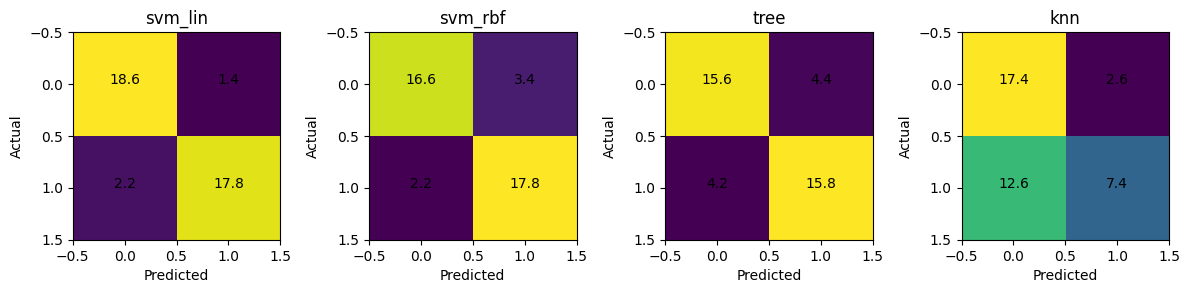

In [23]:
plot_confusion_matrix(cv_cm)